#### Preprocessing code

Extracted from preprovessing matlab code v5, for testing shuffle stability

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import psutil
from functools import partial
from joblib import Parallel, delayed 
import notebook_setup
info = notebook_setup.setup()
# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
from concurrent.futures import ProcessPoolExecutor, as_completed

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


In [2]:
#import local yaml for env preset variables
from analysis_config_loader import load_analysis_config  # new import
config_path = "analysis_config.yaml"  # adjust as needed
analysis_config = load_analysis_config(config_path)

In [3]:
type(analysis_config)
analysis_config
stage_names = analysis_config.task_phase_names
stage_cols =  stage_names
stage_names


['Early_IA_Error',
 'Early_IA_Correct',
 'Late_IA',
 'Early_RS_Error',
 'Early_RS_Correct',
 'Late_RS']

#### Define dataset methods

In [ ]:
#set parameters
data_type_used = "calcium_spikes" #OR, 'dff'
run_activity_enrichment = True
export_mean_active = True
use_WT_CLNZ_folder = False
phase_type = analysis_config.phase_division_types[1]  # 'complex', early vs late and correct vs error
print(phase_type)
# set up locations for input/output #get where to load data 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
print(root_dir)
os.chdir(root_dir)
data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
#make analysis folder 
hour_str = datetime.now().strftime("%H")


complex
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\processed_calcium_spikes


In [5]:
## Matlab file handling functions:
import h5py

def check_corrupted_files(failed_files):
    # Optional Investigate corrupted files
    print("="*70)
    print("INVESTIGATING CORRUPTED FILES")
    print("="*70)

    if len(failed_files) == 0:
        print("No failed files to investigate.")
        return
    
    for fname in failed_files:
        filepath = source_dataset_location / fname
        
        print(f"\n📁 {fname}")
        print("-" * 70)
        
        if not filepath.exists():
            print("   File does not exist!")
            continue
        
        # Check file size
        size_bytes = filepath.stat().st_size
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        
        print(f"  Size: {size_bytes:,} bytes ({size_mb:.2f} MB)")
        
        # Read first bytes to check file signature
        with open(filepath, 'rb') as f:
            header = f.read(100)
        
        # Check for MATLAB file signatures
        print(f"  First 20 bytes (hex): {header[:20].hex()}")
        
        # HDF5 files should start with \x89HDF\r\n\x1a\n
        if header[:4] == b'\x89HDF':
            print("  ✓ Valid HDF5 signature")
        elif header[:4] == b'MATL':
            print("  ⚠️ Old MATLAB format (v5/v6) - needs scipy.io")
        else:
            print(f"   Unknown file signature - file may be corrupted")
            print(f"     Expected: b'\\x89HDF' or b'MATL'")
            print(f"     Got: {header[:4]}")
        
        # Try to detect if file is truncated
        if size_mb < 1:
            print(f"  ⚠️ WARNING: File is unusually small ({size_mb:.2f} MB)")

    # Compare with a working file
    print("\n" + "="*70)
    print("COMPARISON WITH WORKING FILES:")

    # Get file sizes of all working files
    working_sizes = []
    for obj in loaded_objects[:5]:
        fname = obj['name'] + '_dataset_object.mat'
        fpath = source_dataset_location / fname
        if fpath.exists():
            size_mb = fpath.stat().st_size / 1024 / 1024
            working_sizes.append(size_mb)
            print(f"  {fname}: {size_mb:.2f} MB")

    if working_sizes:
        avg_size = sum(working_sizes) / len(working_sizes)
        print(f"\n  Average working file size: {avg_size:.2f} MB")

def load_matlab_object(filepath):
    """Load MATLAB dataset_with_spatial_ROI object from .mat file"""
    # Parse metadata from filename
    filename = filepath.stem.replace('_dataset_object', '')
    parts = filename.split('_')
    
    # Extract name, geno from filename (e.g., "10_3_HET_RS1")
    name = filename
    if len(parts) >= 3:
        geno = parts[2]  # HET or WT
        session = parts[3] if len(parts) > 3 else 'RS1'
    else:
        geno = "UNKNOWN"
        session = "RS1"
    
    try:
        with h5py.File(filepath, 'r') as f:            # Load numeric data from known datasets
            raster = f['#refs#']['i'][()]  # (time, cells)
            # Get deduplicated flag from group x
            deduplicated = f['#refs#']['x']['deduplicated'][0, 0] if 'deduplicated' in f['#refs#']['x'] else False
            # Create object dictionary
            obj = {
                'name': name,
                'geno': geno,
                'session': session,
                'geno_day': None,  # Will need to be set externally if needed
                'raster': raster.T,  # Transpose to (cells, time)
                'deduplicated': bool(deduplicated),
                'good_cells': f['#refs#']['k'][()] if 'k' in f['#refs#'] else None,  # Cell IDs
                'labels': f['#refs#']['j'][()] if 'j' in f['#refs#'] else None,  # Trial/time info
            }
            # Load spatial info if present
            if 'n' in f['#refs#']:
                spatial = f['#refs#']['n']
                obj['spatial_weights'] = spatial['spatial_weights'][()] if 'spatial_weights' in spatial else None
                obj['temporal_weights'] = spatial['temporal_weights'][()] if 'temporal_weights' in spatial else None
                obj['user_labels'] = spatial['user_labels'][()] if 'user_labels' in spatial else None
                obj['subject_name'] = spatial['subject_name'][()] if 'subject_name' in spatial else None
            
            return obj
    
    except (OSError, KeyError) as e:
        print(f"  ERROR loading {filepath.name}: {e}")
        return None


In [ ]:
#get all dataset names
source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name]
print(f"Found {len(content_names)} files in {source_dataset_location}")
for file in content_names:
    print(file.name)

assert len(content_names) == 35, "Number of datasets does not match expected" #verify you are using the correct number of dataset 

Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
10_3_HET_RS1_dataset_object.mat
10_3_HET_RS2_dataset_object.mat
10_3_HET_RS3_dataset_object.mat
13_3_HET_RS1_dataset_object.mat
13_3_HET_RS2_dataset_object.mat
13_3_HET_RS3_dataset_object.mat
13_4_WT_RS1_dataset_object.mat
13_4_WT_RS2_dataset_object.mat
13_5_HET_RS1_dataset_object.mat
13_5_HET_RS2_dataset_object.mat
13_5_HET_RS3_dataset_object.mat
13_6_WT_RS1_dataset_object.mat
13_6_WT_RS2_dataset_object.mat
13_8_HET_RS1_dataset_object.mat
13_8_HET_RS2_dataset_object.mat
13_8_HET_RS3_dataset_object.mat
14_2_WT_RS1_dataset_object.mat
14_2_WT_RS2_dataset_object.mat
15_1_HET_RS1_dataset_object.mat
15_1_HET_RS2_dataset_object.mat
15_1_HET_RS3_dataset_object.mat
5_3_WT_RS1_dataset_object.mat
5_3_WT_RS2_dataset_object.mat
6_2_WT_RS1_dataset_object.mat
6_2_WT_RS2_dataset_object.mat
7_2_WT_RS1_dataset_object.mat
7_4_WT_RS1_dataset_object.mat
7_5_WT_RS1_dataset_ob

In [7]:
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    print(f"Loading file {num}/{len(content_names)}: {file.name}")
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
        print(f"  SKIPPED\n")
        continue
    loaded_objects.append(obj)
    print(f"  {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")

if failed_files:
    print(f"\n Failed files ({len(failed_files)}):")
    for fname in failed_files:
        print(f"  - {fname}")
check_corrupted_files(failed_files)

Loading file 0/35: 10_3_HET_RS1_dataset_object.mat
  10_3_HET_RS1: 136 cells × 150415 frames
Loading file 1/35: 10_3_HET_RS2_dataset_object.mat
  10_3_HET_RS2: 168 cells × 97940 frames
Loading file 2/35: 10_3_HET_RS3_dataset_object.mat
  10_3_HET_RS3: 157 cells × 108794 frames
Loading file 3/35: 13_3_HET_RS1_dataset_object.mat
  13_3_HET_RS1: 160 cells × 191533 frames
Loading file 4/35: 13_3_HET_RS2_dataset_object.mat
  13_3_HET_RS2: 145 cells × 108651 frames
Loading file 5/35: 13_3_HET_RS3_dataset_object.mat
  13_3_HET_RS3: 147 cells × 128277 frames
Loading file 6/35: 13_4_WT_RS1_dataset_object.mat
  13_4_WT_RS1: 183 cells × 153831 frames
Loading file 7/35: 13_4_WT_RS2_dataset_object.mat
  13_4_WT_RS2: 171 cells × 106245 frames
Loading file 8/35: 13_5_HET_RS1_dataset_object.mat
  13_5_HET_RS1: 120 cells × 229350 frames
Loading file 9/35: 13_5_HET_RS2_dataset_object.mat
  13_5_HET_RS2: 125 cells × 141283 frames
Loading file 10/35: 13_5_HET_RS3_dataset_object.mat
  13_5_HET_RS3: 131 cel

#### Import canon TACO

In [8]:

#original taco from 12/10/24 with 1k shuffles
canon_taco = data_dir / Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\main_datasets_complexTACO- neurons_activity by task phase_10-Dec-2024.xls")
canon_taco = pd.read_excel(canon_taco,na_values = -99).replace(-99, np.nan)

#get metadata
frame_cols = [c for c in canon_taco.columns if 'f_' in c]
non_frame_cols = [c for c in canon_taco.columns if 'f_' not in c]
post_stage_names = ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA',
 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct','post_outcome_Late_RS']
print(non_frame_cols)
print(f" Unique canon cells: {canon_taco.groupby(by = 'name')['neuron_ID'].nunique().sum()}")

#get canon/original post taco
canon_post_taco = canon_taco[ post_stage_names +['name','geno_day','geno','neuron_ID']].copy()
canon_post_taco.rename({old:old.replace("post_outcome_","") for old in post_stage_names},axis=1, inplace=True)
canon_post_taco['unique_ID'] = canon_post_taco['name'].str.cat(canon_post_taco['neuron_ID'].astype(str), sep="-")
canon_post_taco

['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'baseline_sig_cells', 'name', 'geno_day', 'geno', 'neuron_ID', 'Var1_1', 'Var1_2', 'Var1_3', 'Var1_4', 'Var1_5', 'Var1_6']
 Unique canon cells: 5961


,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,name,geno_day,geno,neuron_ID,unique_ID
0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1,10_3_HET_RS1-1
1,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2,10_3_HET_RS1-2
2,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3,10_3_HET_RS1-3
3,0.0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4,10_3_HET_RS1-4
4,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5,10_3_HET_RS1-5
...,...,...,...,...,...,...,...,...,...,...,...
5956,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211,9_3_HET_RS3-211
5957,1.0,1,0,0,0,0,9_3_HET_RS3,HET RS3,HET,212,9_3_HET_RS3-212
5958,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213,9_3_HET_RS3-213
5959,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,214,9_3_HET_RS3-214


### Extract and Transform Matlab Objects into stage-labeled dataframes

#### E- dataset objs to dataframes, T- add task stage cols

In [9]:
def dataset_obj_to_df(dataset_obj):
    # Create DataFrame from raster (cells × frames)
    print(f"Processing {dataset_obj['name']}: {dataset_obj['raster'].nbytes} bytes")
    #setup dataset df 
    raster_df = pd.DataFrame(
        dataset_obj['raster'].T,
        index=[f'frame_{i}' for i in range(dataset_obj['raster'].shape[1])],
        columns = [f'cell_{i+1}' for i in range(dataset_obj['raster'].shape[0])],
        dtype = 'Sparse[int]')
            #add labels
    raster_df['labels'] = dataset_obj['labels']
    # Add metadata columns
    #cell Id is represented as col name 
    raster_df['subject_name'] = dataset_obj['name']
    raster_df['geno'] = dataset_obj['geno']
    raster_df['session'] = dataset_obj['session']
    
    return raster_df
#test 1 dataset
test_df = dataset_obj_to_df(loaded_objects[0])
print(test_df.info())
test_df.tail(3)

Processing 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 150415 entries, frame_0 to frame_150414
Columns: 140 entries, cell_1 to session
dtypes: Sparse[int32, 0](136), float64(1), object(3)
memory usage: 9.2+ MB
None


,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,cell_131,cell_132,cell_133,cell_134,cell_135,cell_136,labels,subject_name,geno,session
frame_150412,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150413,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1
frame_150414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,15.0,10_3_HET_RS1,HET,RS1


In [10]:
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError

def add_task_stage_to_raster_df(raster_df, analysis_config):
    """ Joins all the trial stage functions into one function for ease of use (function imported elsewhere).2s per raster 
    #workflow: 
        # 1) Call "trial num at frame" function
        # 2. Add trial number to raster_df
        # 3. drop frames that are not in a trial
        # 4. Add task stage to raster_df based off trial number at frame
    """
    stage_names = analysis_config.task_phase_names
    # 1. Transform frame label vector into trial vector
    labels = raster_df['labels']
    trial_num_at_frame, _, num_trials = return_trial_num_at_frame(labels)
    raster_df.loc[:, 'trial_num'] = trial_num_at_frame 

    # 2. Add trial number to raster_df
    raster_df = raster_df[raster_df['trial_num'] > 0].copy() #  dropping trial_num == 0
    # 4. Add task stage to raster_df based off trial number at frame
    stage_dict = build_phase_masks(labels,analysis_config)
    #5. map trial num to stage
    trial_stage_map = get_trial_stage_map(stage_dict, stage_names, num_trials)
    raster_df.loc[:, 'task_stage'] = raster_df['trial_num'].map(trial_stage_map)


    return raster_df

In [11]:
def label_frame_sections_df(df: pd.DataFrame, label_col: str,*, 
                            section_names=("pre_outcome", "post_outcome", "ITI"),
                            ):
    """
    Vectorized: assign each frame one of {pre_outcome, post_outcome, ITI}. Tie-breaks at 4 (IA) and 11 (RS) go to post_outcome (overwrite order).

    Parameters
    ----------
    df : DataFrame with one row per frame
    label_col : name of column holding per-frame integer labels
    section_names : (pre_outcome, post_outcome, ITI)

    Returns
    -------
    pd.Series (object) of section names aligned to df.index
    """
    pre_outcome, post_outcome, iti = section_names
    labels = df[label_col].to_numpy()
    out = np.full(labels.shape[0], None, dtype=object)

    # IA ranges (2–8)
    ia_pre  = (labels >= 2)  & (labels <= 4)     # pre_outcome
    ia_post = (labels >= 4)  & (labels <= 7)     # post_outcome (overwrites label==4)
    ia_iti  = (labels == 8)                      # ITI

    # RS ranges (9–15)
    rs_pre  = (labels >= 9)  & (labels <= 11)    # pre_outcome
    rs_post = (labels >= 11) & (labels <= 14)    # post_outcome (overwrites label==11)
    rs_iti  = (labels == 15)                     # ITI

    # Overwrite order preserves “boundary goes to later section”:
    out[ia_pre  | rs_pre]  = pre_outcome
    out[ia_post | rs_post] = post_outcome
    out[ia_iti  | rs_iti]  = iti    

    return out

def truncate_post_outcome_to_15s(raster_df, fps=20, max_seconds=15, truncate_post = True):
    """
    Truncate post_outcome periods to first 15 seconds (300 frames at 20fps).
    Modifies task_stage labels for frames beyond truncation.
    """
    max_frames = fps * max_seconds  # 300 frames
    
    raster_df['truncated_post'] =  truncate_post # New column to indicate truncation
    if truncate_post: 
        # For each trial's post_outcome section
        post_outcome_mask = raster_df['trial_section'] == 'post_outcome'
        
        for trial in raster_df['trial_num'].unique():
            if trial <= 0:
                continue
                
            # Get post_outcome frames for this trial
            trial_post = raster_df[post_outcome_mask & (raster_df['trial_num'] == trial)]
            
            if len(trial_post) == 0:
                continue
                
            # Get frame indices (they're sorted)
            frame_indices = trial_post.index
            
            # Mark frames beyond first 300 as truncated
            if len(frame_indices) > max_frames:
                frames_to_truncate = frame_indices[max_frames:]
                raster_df.loc[frames_to_truncate, 'task_stage'] = 'truncated_post_outcome'
        
    return raster_df

In [12]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes = {}

for obj in loaded_objects:    # Create DataFrame from raster (cells × frames)
    raster_df = dataset_obj_to_df(obj)
    raster_df = add_task_stage_to_raster_df(raster_df, analysis_config)
    raster_df['trial_section'] = label_frame_sections_df(raster_df, 'labels', section_names=analysis_config.trial_section_names) #annotate pre,post,ITI
    #new- truncate post-outcome to 15 seconds long, and rename rest to truncated
    raster_df = truncate_post_outcome_to_15s(raster_df, truncate_post = True)
    raster_dataframes[obj['name']] = raster_df
print(f"\nTotal DataFrames created: {len(raster_dataframes)}")

Processing 10_3_HET_RS1: 163651520 bytes
Processing 10_3_HET_RS2: 131631360 bytes
Processing 10_3_HET_RS3: 136645264 bytes
Processing 13_3_HET_RS1: 245162240 bytes
Processing 13_3_HET_RS2: 126035160 bytes
Processing 13_3_HET_RS3: 150853752 bytes
Processing 13_4_WT_RS1: 225208584 bytes
Processing 13_4_WT_RS2: 145343160 bytes
Processing 13_5_HET_RS1: 220176000 bytes
Processing 13_5_HET_RS2: 141283000 bytes
Processing 13_5_HET_RS3: 101650760 bytes
Processing 13_6_WT_RS1: 407216056 bytes
Processing 13_6_WT_RS2: 286371552 bytes
Processing 13_8_HET_RS1: 205506288 bytes
Processing 13_8_HET_RS2: 184071712 bytes
Processing 13_8_HET_RS3: 247363296 bytes
Processing 14_2_WT_RS1: 158077680 bytes
Processing 14_2_WT_RS2: 170570944 bytes
Processing 15_1_HET_RS1: 209435040 bytes
Processing 15_1_HET_RS2: 185898360 bytes
Processing 15_1_HET_RS3: 133253480 bytes
Processing 5_3_WT_RS1: 198030360 bytes
Processing 5_3_WT_RS2: 211466640 bytes
Processing 6_2_WT_RS1: 212864136 bytes
Processing 6_2_WT_RS2: 19240

#### Find post-outcome activity in all raster Dfs

### Retrieve pre-saved Circular shuffle of frame labels 

In [14]:
def get_mean_postoutcome_stage_activity(input_df, cell_col, label_col='task_stage', section_col = 'trial_section', post_outcome_label='post_outcome'):
    """ For groupby operation that returns mean activity for post-outcome stage of each cell in each section """
    mean_section_stage_act = input_df.groupby(by = [label_col, section_col])[cell_col].mean() #325 ms
    return mean_section_stage_act.loc[(slice(None),post_outcome_label),:]    

#unoptimized version for reference
def create_shuffled_df(args):
    """Helper function for parallel processing"""
    df, cell_col, random_seed = args
    roll_data = random_roll_columns(df[cell_col].values, random_seed= random_seed)
    rolled_df = pd.DataFrame(roll_data, columns=cell_col, index=df.index).join(df.drop(columns = cell_col))
    mean_section_stage_act = get_mean_postoutcome_stage_activity(rolled_df, cell_col)
    #new- 11.8.25- add shuffle seed record 
    mean_section_stage_act['shuffle_seed'] = random_seed
    return mean_section_stage_act

# 1s per shuffle is current speed

In [15]:
results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")


In [16]:
run_shuffles = False  #set to True to run shuffles
n_shuf_per_subject = 1000

# Option 1: Global seed sequence across all subjects
#set shuffle storage data folder
run_output_folder = results_dir / Path(f"ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)



 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_19-Nov-2025_1000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_19-Nov-2025_1000 shuffles\shuffled_dfs_1000_per_subject


In [17]:
#function to read parquet shuffle df files
def read_shuffle_parquet_from_folder(shuffle_storage_folder: Path) -> Dict[str, pd.DataFrame]:
    """ Reads  parquet files in folder, containing shuffled mean activity DataFrame """
                # Load all parquet files from that folder

    all_subject_shuffles = {}
    for parquet_file in shuffle_storage_folder.glob("*_shuffled_mean_activity.parquet"):
        subject_name = parquet_file.stem.replace('_shuffled_mean_activity', '')
        all_subject_shuffles[subject_name] = pd.read_parquet(parquet_file)
        print(f" Loaded: {subject_name}")
    
    print(f"Loaded {len(all_subject_shuffles)} subjects from previous run")
    return all_subject_shuffles

#### Extract parquet files and save run record

In [19]:
#load all subject name parquets
# Load from most recent run
shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

if shuffle_run_log_path.exists():
    run_log_df = pd.read_csv(shuffle_run_log_path)
    # Get most recent run
    latest_run = run_log_df.iloc[-1]
    shuffle_storage_folder = Path(latest_run['shuffle_folder'])
    print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles ")
    print(f"  Folder: {shuffle_storage_folder}")
    all_subject_shuffles =  read_shuffle_parquet_from_folder(shuffle_storage_folder) # Load all parquet files from that folder

else:
    print(f"ERROR: No shuffle run log found at {shuffle_run_log_path}")
    print("Please run shuffles first (set run_shuffles=True)")


Loading shuffles from Timestamp: 2025-11-18 17:59:02 | 1000 Shuffles 
  Folder: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\ensemble_detection_18-Nov-2025_1000 shuffles\shuffled_dfs_1000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects fr

In [20]:
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
4,2025-11-18 17:59:02,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42


#### Given shuffle array, run enrichment detection

In [ ]:
## main enrichment analysis function
def get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject):
    ## code for enrichment analysis: given N shuffles, find the 95th percentile value for each cell at each task stage
    cell_threshold = all_shuffle_means.groupby('task_stage')[cell_col].agg(lambda x: np.percentile(x, 95)) #empirical?

    #get real raster mean activity data (DESPARSIFY if necessary)
    for col in cell_col:
        if isinstance(raster_df[col], pd.SparseDtype):
            raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
        raster_df.loc[:, col] = raster_df[col].astype(float)
            
    #group real data by trial_section and task_stage
    real_mean_activity = raster_df.groupby(by = ['trial_section', 'task_stage'])[cell_col].mean().loc['post_outcome', (slice(None))].drop(0)

    # FIX: Only keep stages that exist in both threshold and real data
    common_stages = cell_threshold.index.intersection(real_mean_activity.index)
    cell_threshold = cell_threshold.loc[common_stages]
    real_mean_activity = real_mean_activity.loc[common_stages]

    #get % of shuffle values greater than or equal to real cell activity
    counts_per_cell = []
    for stage, group in all_shuffle_means.groupby("task_stage"):
        # print(f"checking {stage}")
        real_values = real_mean_activity.loc[stage, cell_col] #get % of shuffle greater than or equal to real
        comparison = group[cell_col] >= real_values      # broadcast columnwise
        counts = comparison.sum()                         # count True per cell
        counts.name = stage                               # label this row
        counts_per_cell.append(counts)
    shuf_percentile = pd.DataFrame(counts_per_cell)/n_shuf_per_subject

    #get boolean mask of enriched cells
    enriched_cells = (real_mean_activity > cell_threshold)

    # melt dataframes for joining analysis
    shuf_percentile_long = shuf_percentile.reset_index().melt(id_vars = 'index', var_name = 'cell', value_name = r'percent_shuffle >= real').rename(columns = {'index': 'task_stage'})
    cell_enrich_long = enriched_cells.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'enriched') #cells activity > threshold
    cell_activity_long = real_mean_activity.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'mean') #real mean activity of cells
    cell_thresh_long = cell_threshold.reset_index().melt(id_vars = 'task_stage', var_name = 'cell', value_name = 'percentile_95') #95th percentile of shuffles

    #join dataframes
    cell_ensemble_info = pd.merge(pd.merge(cell_thresh_long, cell_activity_long, on=['task_stage','cell']), cell_enrich_long, on=['task_stage','cell'])
    cell_ensemble_info = pd.merge(cell_ensemble_info, shuf_percentile_long, on=['task_stage','cell'])
    #add subject marker 
    cell_ensemble_info['subject_name'] = raster_df['subject_name'].unique()[0]
    return cell_ensemble_info


## ensemble info for all subjects
def get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject):
    """ Loops through all subjects and computes cell ensemble enrichment info """
    all_subject_ensemble_info = []
    for subject_name, raster_df in raster_dataframes.items():
        print(f"Processing subject: {subject_name}")
        cell_col = [c for c in raster_df.columns if 'cell' in c]
        all_shuffle_means = all_subject_shuffles[subject_name]
        subject_ensemble_info = get_cell_stage_enrichment(all_shuffle_means, raster_df, cell_col, n_shuf_per_subject)
        all_subject_ensemble_info.append(subject_ensemble_info)
    all_ensembles = pd.concat(all_subject_ensemble_info).reset_index(drop=True)
    #add metadata
    all_ensembles['neuron_id'] = all_ensembles['subject_name'] + '-' + all_ensembles['cell'].str.replace('cell_','')
    all_ensembles['date_made'] = datetime.now().strftime("%d-%b-%Y")
    all_ensembles['n_shuffles'] = n_shuf_per_subject
    
    return all_ensembles

In [23]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)

#optional- save ensemble info as parquet
new_python_ens_file = run_output_folder / Path(f"postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
all_ensembles.to_parquet(new_python_ens_file)


Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1
Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
P

#### Within python latest shuffle run, compare within chunk stability


In [24]:
# Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
chunk_size = 1000
print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
chunked_ensemble_results = []
# Loop over each subject
for subject_name, shuffle_df in all_subject_shuffles.items():
    print(f"\n=== Processing subject: {subject_name} ===")
    
    # Get unique seeds for THIS subject
    subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
    n_seeds = len(subject_unique_seeds)
    n_chunks = n_seeds // chunk_size
    print(f"Total seeds for {subject_name}: {n_seeds}")
    print(f"Number of chunks: {n_chunks}")
    # Get corresponding raster data
    subject_raster_df = raster_dataframes[subject_name]
    cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
    
    # Loop over chunks for this subject
    for chunk_idx in range(n_chunks):
        # Get specific seeds for this chunk
        start_idx = chunk_idx * chunk_size
        end_idx = (chunk_idx + 1) * chunk_size
        chunk_seeds = subject_unique_seeds[start_idx:end_idx]
        # print(f"  Chunk {chunk_idx + 1}/{n_chunks}: seeds {chunk_seeds[0]} to {chunk_seeds[-1]} ({len(chunk_seeds)} seeds)")
        chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
        # Run enrichment analysis for this subject-chunk
        chunk_ensembles = get_cell_stage_enrichment(
            all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
        # Add metadata
        chunk_ensembles['subject_name'] = subject_name
        chunk_ensembles['chunk_index'] = chunk_idx
        chunk_ensembles['chunk_seed_min'] = chunk_seeds[0]
        chunk_ensembles['chunk_seed_max'] = chunk_seeds[-1]
        chunk_ensembles['n_seeds_in_chunk'] = len(chunk_seeds)
        chunked_ensemble_results.append(chunk_ensembles)

# Combine all subject-chunk results
all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)

print(f"\n✓ Completed all subjects and chunks")
print(f"Total results shape: {all_chunked_ensembles.shape}")
print(f"Subjects processed: {all_chunked_ensembles['subject_name'].nunique()}")
print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")

all_chunked_ensembles.head()

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1 ===
Total seeds for 10_3_HET_RS1: 1000
Number of chunks: 1

=== Processing subject: 10_3_HET_RS2 ===
Total seeds for 10_3_HET_RS2: 1000
Number of chunks: 1

=== Processing subject: 10_3_HET_RS3 ===
Total seeds for 10_3_HET_RS3: 1000
Number of chunks: 1

=== Processing subject: 13_3_HET_RS1 ===
Total seeds for 13_3_HET_RS1: 1000
Number of chunks: 1

=== Processing subject: 13_3_HET_RS2 ===
Total seeds for 13_3_HET_RS2: 1000
Number of chunks: 1

=== Processing subject: 13_3_HET_RS3 ===
Total seeds for 13_3_HET_RS3: 1000
Number of chunks: 1

=== Processing subject: 13_4_WT_RS1 ===
Total seeds for 13_4_WT_RS1: 1000
Number of chunks: 1

=== Processing subject: 13_4_WT_RS2 ===
Total seeds for 13_4_WT_RS2: 1000
Number of chunks: 1

=== Processing subject: 13_5_HET_RS1 ===
Total seeds for 13_5_HET_RS1: 1000
Number of chunks: 1

=== Processing subject: 13_5_HET_RS2 ===
Total seeds for 13_5_HET_RS2: 1000
Number 

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,chunk_index,chunk_seed_min,chunk_seed_max,n_seeds_in_chunk
0,Early_IA_Correct,cell_1,0.095083,0.000000,False,1.0,10_3_HET_RS1,0,9404214,2145561071,1000
1,Early_IA_Error,cell_1,0.157000,0.686667,True,0.0,10_3_HET_RS1,0,9404214,2145561071,1000
2,Early_RS_Correct,cell_1,0.126667,0.000000,False,1.0,10_3_HET_RS1,0,9404214,2145561071,1000
3,Early_RS_Error,cell_1,0.143417,0.000000,False,1.0,10_3_HET_RS1,0,9404214,2145561071,1000
4,Late_IA,cell_1,0.101333,0.000000,False,1.0,10_3_HET_RS1,0,9404214,2145561071,1000


In [ ]:
enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index', values='enriched',aggfunc='first')

enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
chunk_col = [c for c in enriched_by_chunk.columns if 'chunk_' in c]
# Add summary columns
enriched_by_chunk['n_chunks_enriched'] = enriched_by_chunk.sum(axis=1)  # Count True across chunks
enriched_by_chunk['pct_chunks_enriched'] = enriched_by_chunk['n_chunks_enriched'] / len(chunk_col) * 100
enriched_by_chunk = enriched_by_chunk.reset_index()
enriched_by_chunk.head()

,subject_name,task_stage,cell,chunk_0,n_chunks_enriched,pct_chunks_enriched
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,0,0.0
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,0,0.0
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,0,0.0
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,0,0.0
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,0,0.0


#### import canon parquet, old and new Matlab TACOS


In [26]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())

#get ensemble info from canon df
canon_ensembles  = canonical_data.groupby(by = ['unique_ID', 'geno', 'geno_day'])[stage_cols].first()
canon_ensembles.tail(3)

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,,,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
unique_ID,geno,geno_day,,,,,,
9_3_HET_RS3-97,HET,Het postCLNZ,1.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-98,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0
9_3_HET_RS3-99,HET,Het postCLNZ,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
#ran matlb ensemble detection 11/13/25 at 8pm
new_taco = data_dir / Path(r"WT_CLNZ_complexTACO- neurons_activity by task phase_18-Nov-2025.xls")
new_taco = pd.read_excel(new_taco,na_values = -99).replace(-99, np.nan)

#get metadata
frame_cols = [c for c in canon_taco.columns if 'f_' in c]
non_frame_cols = [c for c in canon_taco.columns if 'f_' not in c]
post_stage_names = ['post_outcome_Early_IA_Error','post_outcome_Early_IA_Correct','post_outcome_Late_IA',
 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct','post_outcome_Late_RS']
print(non_frame_cols)
print(f" Unique canon cells: {canon_taco.groupby(by = 'name')['neuron_ID'].nunique().sum()}")

#get only post-outcome stages
new_taco_post = new_taco[post_stage_names+ ['name','geno_day','geno','neuron_ID']].copy()
new_taco_post.rename({old:old.replace("post_outcome_","") for old in post_stage_names}, axis=1, inplace=True)
new_taco_post['unique_ID'] =new_taco_post['name'].str.cat(new_taco_post['neuron_ID'].astype(str), sep="-")



['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'baseline_sig_cells', 'name', 'geno_day', 'geno', 'neuron_ID', 'Var1_1', 'Var1_2', 'Var1_3', 'Var1_4', 'Var1_5', 'Var1_6']
 Unique canon cells: 5961


#### Compare MATLAB- 10 1000 shuffle draws for 1 subject

In [ ]:
test_flag = "test"
test_folder = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\MATLAB Single Subject Test Data")

## read and import all xls files in test folder
all_xls_files = [x for x in test_folder.glob("*.xls") if test_flag in x.stem]
all_test_dfs = []
for xls_file in all_xls_files:
    test_n  = xls_file.stem.split('_')[1]
    df = pd.read_excel(xls_file)
    df["test_num"] = test_n
    all_test_dfs.append(df)

#join all loaded test chunks
matlab_test_chunks = pd.concat(all_test_dfs).reset_index(drop=True)
matlab_stage_cols = ['post_outcome_Early_IA_Error', 'post_outcome_Early_IA_Correct', 'post_outcome_Late_IA', 'post_outcome_Early_RS_Error', 'post_outcome_Early_RS_Correct', 'post_outcome_Late_RS'] 
matlab_metacol = ['name', 'geno_day', 'neuron_ID', 'test_num']
matlab_test_df = matlab_test_chunks[matlab_metacol + matlab_stage_cols].rename(columns = {old:old.replace("post_outcome_","") for old in matlab_stage_cols})
matlab_test_df['neuron_ID'] = matlab_test_df['name'] + '-' + matlab_test_df['neuron_ID'].astype(str)
matlab_test_df.test_num = matlab_test_df.test_num.astype(int)
matlab_test_df.tail()

,name,geno_day,neuron_ID,test_num,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
1355,10_3_HET_RS1,HET RS1,10_3_HET_RS1-132,9,0,0,0,0,0,0
1356,10_3_HET_RS1,HET RS1,10_3_HET_RS1-133,9,1,0,0,1,0,0
1357,10_3_HET_RS1,HET RS1,10_3_HET_RS1-134,9,0,0,0,0,0,0
1358,10_3_HET_RS1,HET RS1,10_3_HET_RS1-135,9,0,0,0,0,0,0
1359,10_3_HET_RS1,HET RS1,10_3_HET_RS1-136,9,1,0,1,1,0,0


In [41]:
#make long format for comparison
matlab_test_long = matlab_test_df.melt(id_vars = matlab_metacol, var_name = 'task_stage', value_name = 'enriched')
print(matlab_test_long.sample())
enrich_matlab_test = matlab_test_long.pivot_table(index=['name', 'task_stage', 'neuron_ID'], columns='test_num', values='enriched', aggfunc='first')
enrich_matlab_test.columns = [f'chunk_{i}' for i in enrich_matlab_test.columns]
chunk_col = [c for c in enrich_matlab_test.columns if 'chunk_' in c]
# Add summary columns
enrich_matlab_test['n_chunks_enriched'] = enrich_matlab_test.sum(axis=1)  # Count True across chunks
enrich_matlab_test['pct_chunks_enriched'] = enrich_matlab_test['n_chunks_enriched'] / len(chunk_col) * 100
enrich_matlab_test = enrich_matlab_test.reset_index()
enrich_matlab_test.head(3)

              name geno_day        neuron_ID  test_num task_stage  enriched
3187  10_3_HET_RS1  HET RS1  10_3_HET_RS1-60         3    Late_IA         0


,name,task_stage,neuron_ID,chunk_1,chunk_2,chunk_3,chunk_4,chunk_5,chunk_6,chunk_7,chunk_8,chunk_9,chunk_10,n_chunks_enriched,pct_chunks_enriched
0,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-1,0,0,0,0,0,0,0,0,0,0,0,0.0
1,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-10,0,0,0,0,0,0,0,0,0,0,0,0.0
2,10_3_HET_RS1,Early_IA_Correct,10_3_HET_RS1-100,0,0,0,0,0,0,0,0,0,0,0,0.0


Text(0.5, 1.0, 'MATLAB |  Correlation of enrichment from 10 ind. blocks of 1000 shuffles in 1 subject')

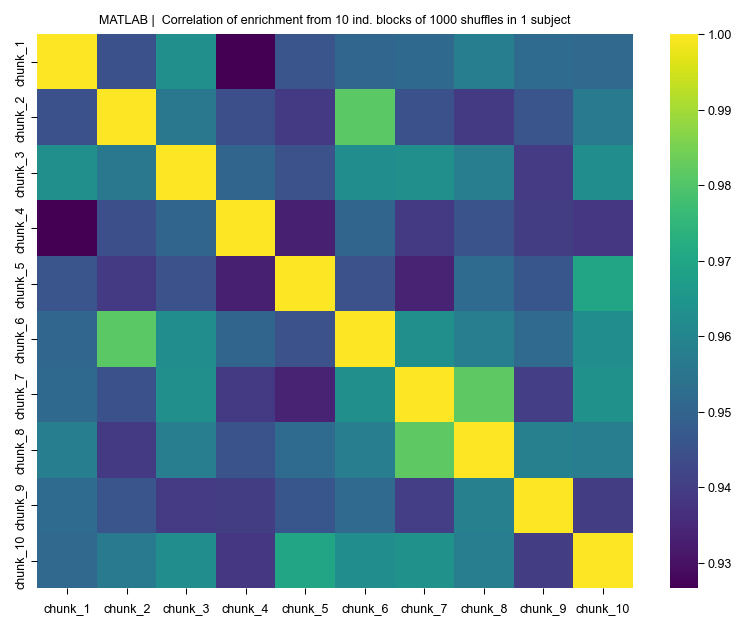

In [45]:
matlab_test_corr = enrich_matlab_test[chunk_col].corr()

sns.heatmap(enrich_matlab_test[chunk_col].corr(), vmax = 1, cmap='viridis')   
plt.title(f"MATLAB |  Correlation of enrichment from 10 ind. blocks of 1000 shuffles in 1 subject")

#### Compare MATLAB OLD TACO enrichment vectors with NEWEST PYTHON enrichment vector

In [48]:
#combine OG taco with new ensembles
combined_ens = canon_post_taco.set_index('unique_ID').join(ens_matrix.astype(float), how = 'inner', rsuffix = '_new')
# Compute correlation for each stage
correlations = {stage: combined_ens[stage].corr(combined_ens[stage + '_new']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of Paper's MATLAB ensembles & Python adapted ens. detection method: \n{corr_df}")

 Correlation of Paper's MATLAB ensembles & Python adapted ens. detection method: 
                  Correlation
Early_IA_Error       0.913771
Early_IA_Correct     0.923618
Late_IA              0.919340
Early_RS_Error       0.898472
Early_RS_Correct     0.873438
Late_RS              0.915495


#### Compare MATLAB OLD vs MATLAB NEW enrichment vectors

In [35]:
#compare latest MATLAB TACO with old matlab TACO (used in papwer)
taco_old_new = new_taco_post.set_index('unique_ID').loc[:,stage_names].join(canon_post_taco.set_index('unique_ID'), how = 'inner', rsuffix = '_new')
taco_old_new

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,Early_IA_Error_new,Early_IA_Correct_new,Late_IA_new,Early_RS_Error_new,Early_RS_Correct_new,Late_RS_new,name,geno_day,geno,neuron_ID
unique_ID,,,,,,,,,,,,,,,,
10_3_HET_RS1-1,1.0,0,0,0,0,0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,1
10_3_HET_RS1-2,0.0,0,0,0,0,0,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,2
10_3_HET_RS1-3,1.0,0,0,0,0,0,1.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,3
10_3_HET_RS1-4,0.0,0,0,1,0,0,0.0,0,0,1,0,0,10_3_HET_RS1,HET RS1,HET,4
10_3_HET_RS1-5,0.0,0,0,0,0,0,0.0,0,0,0,0,0,10_3_HET_RS1,HET RS1,HET,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9_3_HET_RS3-211,0.0,0,0,0,0,0,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,211
9_3_HET_RS3-212,1.0,1,0,0,0,0,1.0,1,0,0,0,0,9_3_HET_RS3,HET RS3,HET,212
9_3_HET_RS3-213,0.0,0,0,0,0,0,0.0,0,0,0,0,0,9_3_HET_RS3,HET RS3,HET,213


In [51]:
print(f"Newest MATLAB RUN: ensemble % enriched across all cells: \n{new_taco_post[stage_names].mean()}")
print(f"Paper's ensembles: ensemble % enriched across all cells: \n{canon_post_taco[stage_names].mean()}")

Newest MATLAB RUN: ensemble % enriched across all cells: 
Early_IA_Error      0.098071
Early_IA_Correct    0.108371
Late_IA             0.077672
Early_RS_Error      0.057373
Early_RS_Correct    0.054353
Late_RS             0.038584
dtype: float64
Paper's ensembles: ensemble % enriched across all cells: 
Early_IA_Error      0.098277
Early_IA_Correct    0.105351
Late_IA             0.080523
Early_RS_Error      0.057876
Early_RS_Correct    0.053682
Late_RS             0.039423
dtype: float64


In [52]:
##compare old vs new taco ensembles
correlations = {stage: taco_old_new[stage].corr(taco_old_new[stage + '_new']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment for Paper ensembles  vs NEW Matlab run (same code): \n{corr_df}")

 Correlation of enrichment for Paper ensembles  vs NEW Matlab run (same code): 
                  Correlation
Early_IA_Error       0.924686
Early_IA_Correct     0.952663
Late_IA              0.950668
Early_RS_Error       0.930503
Early_RS_Correct     0.931079
Late_RS              0.935162


## Split-Half Reliability Test

Test: What correlation do we expect when running the SAME permutation method twice with different random seeds?

In [53]:
# Split-half reliability test: Run Python method twice with different seed sets
print("SPLIT-HALF RELIABILITY TEST")
print("Testing: Same algorithm, different RNG seeds")
print()
test_subject = "10_3_HET_RS1"
test_raster_df = raster_dataframes[test_subject]
cell_cols = [c for c in test_raster_df.columns if c.startswith("cell_")]

# Run 1: Seeds 1000-1999 (simulating "Run A")
print("Running shuffle set A (seeds 1000-1999)...")
shuffle_means_A = []
for seed in range(1000, 2000):
    rolled = random_roll_columns(test_raster_df[cell_cols].values, random_seed=seed)
    rolled_df = pd.DataFrame(rolled, columns=cell_cols, index=test_raster_df.index).join(
        test_raster_df.drop(columns=cell_cols)
    )
    mean_act = rolled_df[
        rolled_df["trial_section"] == "post_outcome"
    ].groupby("task_stage")[cell_cols].mean()
    shuffle_means_A.append(mean_act)

all_shuffles_A = pd.concat(shuffle_means_A, axis=0, keys=range(1000))

# Run 2: Seeds 2000-2999 (simulating "Run B")
print("Running shuffle set B (seeds 2000-2999)...")
shuffle_means_B = []
for seed in range(2000, 3000):
    rolled = random_roll_columns(test_raster_df[cell_cols].values, random_seed=seed)
    rolled_df = pd.DataFrame(rolled, columns=cell_cols, index=test_raster_df.index).join(
        test_raster_df.drop(columns=cell_cols)
    )
    mean_act = rolled_df[
        rolled_df["trial_section"] == "post_outcome"
    ].groupby("task_stage")[cell_cols].mean()
    shuffle_means_B.append(mean_act)

all_shuffles_B = pd.concat(shuffle_means_B, axis=0, keys=range(1000))

# Calculate 95th percentile thresholds for each run
print()
print("Calculating enrichment calls...")
thresholds_A = all_shuffles_A.groupby("task_stage")[cell_cols].agg(lambda x: np.percentile(x, 95))
thresholds_B = all_shuffles_B.groupby("task_stage")[cell_cols].agg(lambda x: np.percentile(x, 95))

# Get real activity
real_activity = test_raster_df[
    test_raster_df["trial_section"] == "post_outcome"
].groupby("task_stage")[cell_cols].mean()

# Determine enrichment for each run
enriched_A = (real_activity > thresholds_A).astype(int)
enriched_B = (real_activity > thresholds_B).astype(int)

print()
print("="*60)
print("RESULTS: Correlation between Run A and Run B")
print("="*60)

stages = ["Early_IA_Error", "Early_IA_Correct", "Late_IA", 
          "Early_RS_Error", "Early_RS_Correct", "Late_RS"]

print(f"{"Stage":<20} {"Correlation":<15} {"Agreement %":<15} {"Enriched A":<12} {"Enriched B":<12}")
print("-" * 75)

correlations = {}
for stage in stages:
    if stage in enriched_A.index:
        corr = enriched_A.loc[stage].corr(enriched_B.loc[stage])
        agreement = (enriched_A.loc[stage] == enriched_B.loc[stage]).mean()
        rate_A = enriched_A.loc[stage].mean()
        rate_B = enriched_B.loc[stage].mean()
        
        correlations[stage] = corr
        print(f"{stage:<20} {corr:<15.3f} {agreement:<15.1%} {rate_A:<12.1%} {rate_B:<12.1%}")

print()
print(f"Mean correlation across stages: {np.mean(list(correlations.values())):.3f}")
print()
print("INTERPRETATION:")
print("This correlation represents the EXPECTED agreement when using")
print("the same method twice with different random seeds.")
print("Your Python vs MATLAB correlation should be compared to this baseline.")

SPLIT-HALF RELIABILITY TEST
Testing: Same algorithm, different RNG seeds

Running shuffle set A (seeds 1000-1999)...


NameError: name 'random_roll_columns' is not defined

## Data Integrity Check

Since split-half correlation is 0.94 but Python-MATLAB is 0.31, the issue must be in the INPUT DATA, not the shuffle algorithm.

## Performance Optimizations

Optimized shuffle functions for frequent reanalysis and high shuffle counts.

In [ ]:
# BENCHMARK: Compare old vs new performance
import time

test_subject = list(raster_dataframes.keys())[0]
test_df = raster_dataframes[test_subject]
test_cell_col = [c for c in test_df.columns if "cell" in c]
n_test_shuff = 500
print(f"Benchmarking on: {test_subject}")
print(f"Data shape: {test_df[test_cell_col].shape}")
print(f"Testing {n_test_shuff} shuffles...")

# Test OLD version
start = time.time()
output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df)((subject_raster_df, cell_col, int(seed))) 
            for seed in range(n_test_shuff))


old_time = time.time() - start
print(f"OLD version: {old_time:.2f} seconds")

# Test NEW version
start = time.time()
output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
    delayed(create_shuffled_df_optimized)((test_df, test_cell_col, int(seed))) for seed in range(n_test_shuff))
new_time = time.time() - start
print(f"NEW version: {new_time:.2f} seconds")

speedup = old_time / new_time
print(f"Speedup: {speedup:.1f}x faster")
print(f"For 1000 shuffles per subject:")
print(f"  OLD: ~{old_time * 10:.1f} seconds ({old_time * 10 / 60:.1f} minutes)")
print(f"  NEW: ~{new_time * 10:.1f} seconds ({new_time * 10 / 60:.1f} minutes)")
print(f"For all {len(raster_dataframes)} subjects with 1000 shuffles:")
print(f"  OLD: ~{old_time * 10 * len(raster_dataframes) / 60:.1f} minutes")
print(f"  NEW: ~{new_time * 10 * len(raster_dataframes) / 60:.1f} minutes")